# Tic-Tac-Toe: MiniMax y Monte Carlo Tree Search

## El juego

Tic-Tac-Toe (tres en línea) es un juego de **suma cero**, **información perfecta** y **horizonte finito** entre dos agentes, `X` y `O`, que se alternan turnos:

- **Estado:** tablero de 3x3. Cada celda está vacía, o tiene una marca `X` u `O`.
- **Acciones:** en cada turno, el agente que mueve elige una celda vacía (`game.available_actions()`).
- **Fin del juego:** termina cuando un jugador alinea 3 marcas propias (fila, columna o diagonal) o cuando se llena el tablero sin que nadie alinee (empate).
- **Tamaño del árbol de juego:** acotado por `9! = 362.880` secuencias de jugadas posibles (en la práctica bastante menos por las terminaciones tempranas), lo que lo hace tratable para una búsqueda exhaustiva — es justamente lo que permite usarlo como caso de validación donde se conoce el valor óptimo del juego.

## Valores que puede tomar un agente

Hay dos nociones de "valor" distintas que aparecen en el código y conviene no confundir:

1. **Recompensa terminal — `game.reward(agent)`:** sólo está definida al terminar la partida y toma exactamente uno de tres valores:
   - `+1` si `agent` ganó,
   - `-1` si `agent` perdió,
   - `0` si la partida terminó en empate.
   
   Por ser un juego de suma cero entre 2 jugadores, `reward('X') = -reward('O')` siempre.

2. **Evaluación heurística — `game.eval(agent)`:** definida también en estados *no terminales*, da un valor continuo en `[-1, 1]` que cuenta, para cada jugador, cuántas líneas (filas/columnas/diagonales) siguen "abiertas" (sin marcas del rival) y resta esos conteos normalizados. Es la función que usa `MiniMax` para evaluar nodos cuando se corta la búsqueda antes de llegar a un estado terminal (parámetro `depth`).

   Como consecuencia, los valores que reporta cada agente en los experimentos también viven en `[-1, 1]`:
   - El valor que devuelve `MiniMax.minimax(...)` es exacto (`±1`/`0`) si `depth` alcanza para llegar a estados terminales, o una aproximación heurística si se corta antes.
   - El valor de un nodo en `MonteCarloTreeSearch` (`mean_reward`, ver `agents/tree_search.py`) es el promedio de las recompensas terminales (`±1`/`0`) obtenidas en los rollouts que pasaron por ese nodo, así que también cae en `[-1, 1]` y converge al valor minimax exacto a medida que crecen las simulaciones (Ley de Grandes Números + UCT).

## Equilibrio del juego

Tic-Tac-Toe es un juego **resuelto**: al ser finito, determinista, de suma cero y con información perfecta, el teorema de Zermelo garantiza que tiene un **valor minimax bien definido**, calculable por inducción hacia atrás (exactamente lo que hace `MiniMax` con `depth` suficiente).

- El valor del juego, jugando ambos jugadores de forma óptima, es **empate (`0`)**: ningún jugador puede forzar una victoria si el rival juega perfecto.
- El primer jugador (`X`) puede **garantizar al menos un empate** (y ganar si `O` comete un error); las aperturas óptimas conocidas son el centro o una esquina.
- Este par de estrategias óptimas (una para cada agente) constituye el **equilibrio de Nash** del juego — en un juego de suma cero de 2 jugadores con información perfecta, el equilibrio de Nash coincide con el par de estrategias minimax (es un *punto de silla* del valor del juego).

Esto da una vara de medida muy concreta para validar los algoritmos de aprendizaje en este ambiente:

- `MiniMax` con `depth` igual a la profundidad máxima del árbol calcula el equilibrio exacto (ver Experimento 4 más abajo).
- `MCTS` sólo se acerca a ese equilibrio de forma aproximada y depende del presupuesto de cómputo (`simulations`, `rollouts`); el objetivo de la experimentación es cuantificar **qué tan cerca** llega y a qué costo, comparado contra un oponente aleatorio y contra MiniMax con distintas profundidades.

In [2]:
from games.tictactoe.tictactoe import TicTacToe
from agents.agent_random import RandomAgent
from agents.minimax import MiniMax
import numpy as np
from collections import defaultdict

In [3]:
game = TicTacToe(render_mode='')

In [239]:
agents_rd = dict(map(lambda agent: (agent, RandomAgent(game=game, agent=agent)), game.agents))
agents_rd

{'X': <agents.agent_random.RandomAgent at 0x122dbd8d0>,
 'O': <agents.agent_random.RandomAgent at 0x1224fd790>}

In [240]:
game.reset()
while not game.terminated():
    game.render()
    print(game.eval(game.agent_selection))
    action = agents_rd[game.agent_selection].action()
    game.step(action)
game.render()
print(game.eval(game.agent_selection))
print(game.rewards)

Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

0.0
Player: O
Board:
 .  .  . 
 .  .  X 
 .  .  . 

-0.25
Player: X
Board:
 .  .  . 
 .  O  X 
 .  .  . 

-0.25
Player: O
Board:
 .  .  . 
 .  O  X 
 .  .  X 

0.0
Player: X
Board:
 O  .  . 
 .  O  X 
 .  .  X 

-0.25
Player: O
Board:
 O  .  . 
 X  O  X 
 .  .  X 

0.125
Player: X
Board:
 O  .  . 
 X  O  X 
 O  .  X 

-0.25
Player: O
Board:
 O  .  . 
 X  O  X 
 O  X  X 

0.125
Player: X
Board:
 O  .  O 
 X  O  X 
 O  X  X 

-1
{'X': -1, 'O': 1}


In [241]:
players = {}
players[game.agents[0]] = MiniMax(game=game, agent=game.agents[0], depth=1)
players[game.agents[1]] = MiniMax(game=game, agent=game.agents[1], depth=4)


In [242]:
game.reset()
game.render()
print(game.observe(game.agents[0]))
action, value = players[game.agent_selection].minimax(game, depth=1)
print(action, value)
game.step(action)
game.render()
print(game.observe(game.agents[1]))
action, value = players[game.agent_selection].minimax(game, depth=4)
game.step(action)
print(action, value)
game.render()


Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

[[0 0 0]
 [0 0 0]
 [0 0 0]]
4 0.5
Player: O
Board:
 .  .  . 
 .  X  . 
 .  .  . 

[[0 0 0]
 [0 2 0]
 [0 0 0]]
6 -0.375
Player: X
Board:
 O  .  . 
 .  X  . 
 O  .  . 



In [243]:
values = defaultdict(list)
N = 10
for i in range(N):    
    game.reset()
    while not game.terminated():
        agent = game.agent_selection
        action = players[agent].action()
        game.step(action)
    for agent in game.agents:
        values[agent].append(game.reward(agent))
for agent in game.agents:
    print(f"Agent {agent} average reward: {np.mean(values[agent])} over {N} games")
    print(f"Agent {agent} rewards: {values[agent]}")

Agent X average reward: 0.0 over 10 games
Agent X rewards: [-1, 1, -1, 1, -1, -1, 1, 1, -1, 1]
Agent O average reward: 0.0 over 10 games
Agent O rewards: [1, -1, 1, -1, 1, 1, -1, -1, 1, -1]


## Experimentos: MiniMax y MCTS

En todos los experimentos, **agente 0 juega N partidas como X (primer jugador) y N partidas como O (segundo jugador)**; los resultados se combinan desde la perspectiva de agente 0 para que el resultado no dependa de quién mueve primero. Cada sección incluye una gráfica de convergencia al Nash equilibrium (línea roja, reward = 0 = empate) y una de costo computacional.

Los experimentos están organizados en cuatro bloques:

1. **MiniMax vs MiniMax** — variando la profundidad de 1 a 9: a depth=9 MiniMax es el jugador Nash exacto (árbol completo), por lo que el reward converge a 0 con depth suficiente.
2. **MCTS vs MCTS — simulaciones** — efecto del número de simulaciones, ambos agentes con el mismo presupuesto y rollouts=10.
3. **MCTS vs MCTS — rollouts** — efecto del número de rollouts, ambos agentes con simulations=50.
4. **MCTS vs MiniMax** — comparación directa: agente 0 es MCTS (simulaciones variables), agente 1 es MiniMax (profundidad variable).

In [4]:
import os
import math
import time
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from agents.mcts_t import MonteCarloTreeSearch

# El notebook corre con cwd = 'Alternating Games', así que el informe (carpeta hermana) queda un nivel arriba.
FIGURES_DIR = os.path.join('..', 'informe', 'figures', 'TicTacToe')
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Figura guardada en {path}")

# nombre del experimento -> (tiempo total de cómputo en segundos, partidas jugadas)
experiment_times = {}

# Formato de ejes: números planos (5, 10, 25...) en vez de notación 10^x en escala log.
PLAIN_FMT = FuncFormatter(lambda v, _: f'{v:g}')

def plain_log_xticks(ax, ticks):
    """Fuerza los ticks del eje X (escala log) a los valores experimentados, con etiquetas planas."""
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(PLAIN_FMT)
    ax.xaxis.set_minor_formatter(NullFormatter())

def plain_log_yticks(ax):
    """Etiquetas planas para los ticks (automáticos) del eje Y en escala log."""
    ax.yaxis.set_major_formatter(PLAIN_FMT)
    ax.yaxis.set_minor_formatter(NullFormatter())

def set_log_ylim_nice(ax, *data_series):
    """Ajusta los límites del eje Y en escala log para que el tick superior e inferior sean visibles."""
    all_vals = [v for s in data_series for v in s if v > 0]
    if not all_vals:
        return
    ymin, ymax = min(all_vals), max(all_vals)
    lo = 10 ** math.floor(math.log10(ymin) - 0.2)
    hi = 10 ** math.ceil(math.log10(ymax) + 0.2)
    ax.set_ylim(lo, hi)

### Demostración: una partida MCTS (X) vs Random (O)

In [245]:
demo_players = {
    'X': MonteCarloTreeSearch(game=game, agent='X', simulations=100, rollouts=10),
    'O': RandomAgent(game=game, agent='O'),
}

game.reset()
game.render()
while not game.terminated():
    agent = game.agent_selection
    action = demo_players[agent].action()
    game.step(action)
    game.render()
print(game.rewards)

Player: X
Board:
 .  .  . 
 .  .  . 
 .  .  . 

Player: O
Board:
 .  X  . 
 .  .  . 
 .  .  . 

Player: X
Board:
 .  X  . 
 O  .  . 

Player: O
Board:
 X  .  . 
 .  X  . 
 O  .  . 

Player: X
Board:
 X  O  . 
 .  X  . 
 O  .  . 

Player: O
Board:
 X  O  . 
 .  X  . 
 O  .  X 

{'X': 1, 'O': -1}


### Función auxiliar de experimentación

`run_match` juega `n_games` partidas entre dos agentes (definidos por tipo y parámetros) y registra, por partida, la recompensa final y el tiempo promedio de decisión de cada agente.

In [7]:
def make_agent(kind, game, agent_id, **kwargs):
    if kind == 'random':
        return RandomAgent(game=game, agent=agent_id)
    if kind == 'mcts':
        return MonteCarloTreeSearch(
            game=game, agent=agent_id,
            simulations=kwargs.get('simulations', 100),
            rollouts=kwargs.get('rollouts', 10),
        )
    if kind == 'minimax':
        return MiniMax(game=game, agent=agent_id, depth=kwargs.get('depth', 4))
    raise ValueError(f"Unknown agent kind: {kind}")


def run_match(game, agent_specs, n_games=100):
    """
    agent_specs: dict {agent_id: (kind, kwargs)}
    Devuelve un DataFrame con una fila por partida: reward_<agent>, avg_time_<agent>, n_moves_<agent>.
    """
    agents = {aid: make_agent(kind, game, aid, **kwargs) for aid, (kind, kwargs) in agent_specs.items()}
    rows = []
    for i in range(n_games):
        game.reset()
        agent_times = {aid: [] for aid in agent_specs}
        while not game.terminated():
            aid = game.agent_selection
            t0 = time.perf_counter()
            action = agents[aid].action()
            t1 = time.perf_counter()
            agent_times[aid].append(t1 - t0)
            game.step(action)
        row = {'game': i}
        for aid in agent_specs:
            row[f'reward_{aid}'] = game.reward(aid)
            row[f'avg_time_{aid}'] = float(np.mean(agent_times[aid])) if agent_times[aid] else 0.0
            row[f'n_moves_{aid}'] = len(agent_times[aid])
        
        rows.append(row)
    return pd.DataFrame(rows)

In [11]:
NASH_TICTACTOE = 0.0  # TicTacToe resuelto: juego óptimo de ambos lados → empate (reward = 0)

def run_symmetric(game, agente0_spec, agente1_spec, n_games_per_side):
    """
    Corre n_games_per_side con agente 0 como X y n_games_per_side con agente 0 como O.
    Devuelve (rewards_a0, times_a0, times_a1) como pandas Series combinadas.
    """
    df_r1 = run_match(game, {'X': agente0_spec, 'O': agente1_spec}, n_games=n_games_per_side)
    df_r2 = run_match(game, {'O': agente0_spec, 'X': agente1_spec}, n_games=n_games_per_side)
    rewards_a0 = pd.concat([df_r1['reward_X'], df_r2['reward_O']], ignore_index=True)
    times_a0   = pd.concat([df_r1['avg_time_X'], df_r2['avg_time_O']], ignore_index=True)
    times_a1   = pd.concat([df_r1['avg_time_O'], df_r2['avg_time_X']], ignore_index=True)
    return rewards_a0, times_a0, times_a1

### Experimento 1 — MiniMax vs MiniMax: efecto de la profundidad

Se enfrenta MiniMax(depth=d) **simétrico** variando `d` de 1 a 9. **Agente 0 juega `N_GAMES_MM_SIDE` partidas como X y `N_GAMES_MM_SIDE` como O** para cancelar el efecto de la posición.

- A depth=9 el árbol es completo: MiniMax es el jugador Nash exacto → el resultado teórico es empate (reward = 0).
- A profundidades menores usa la heurística `eval()`, por lo que puede cometer errores y el resultado se aleja de 0.
- MiniMax es **determinístico** dado un estado, por lo que pocas partidas por lado son suficientes. Las profundidades altas (≥7) son costosas sin poda alfa-beta.

In [12]:
depth_grid_mm = [1, 2, 3, 4, 5, 6, 7, 8, 9]
N_GAMES_MM_SIDE = 3  # por lado (X y O) → 6 partidas por profundidad
                     # depth≥7 sin poda alfa-beta es costoso; aumentar para depths bajas si se desea

t0 = time.perf_counter()
rows = []
for depth in depth_grid_mm:
    print(f"[Exp1] depth={depth} ...", end=" ", flush=True)
    agente0_spec = ('minimax', dict(depth=depth))
    agente1_spec = ('minimax', dict(depth=depth))
    rewards_a0, times_a0, times_a1 = run_symmetric(game, agente0_spec, agente1_spec, N_GAMES_MM_SIDE)
    n_total = 2 * N_GAMES_MM_SIDE
    avg_r = float(rewards_a0.mean())
    print(f"avg_reward={avg_r:+.3f}  (W={int((rewards_a0==1).sum())} D={int((rewards_a0==0).sum())} L={int((rewards_a0==-1).sum())})")
    rows.append(dict(
        depth=depth,
        wins_agente0=int((rewards_a0 == 1).sum()),
        draws=int((rewards_a0 == 0).sum()),
        wins_agente1=int((rewards_a0 == -1).sum()),
        n_games=n_total,
        win_rate_agente0=float((rewards_a0 == 1).mean()),
        draw_rate=float((rewards_a0 == 0).mean()),
        win_rate_agente1=float((rewards_a0 == -1).mean()),
        avg_reward_agente0=avg_r,
        avg_time_agente0_ms=float(times_a0.mean()) * 1000,
        avg_time_agente1_ms=float(times_a1.mean()) * 1000,
    ))
experiment_times['Exp1: MiniMax vs MiniMax (depth 1–9)'] = (
    time.perf_counter() - t0, len(depth_grid_mm) * 2 * N_GAMES_MM_SIDE)

df_exp1 = pd.DataFrame(rows)
df_exp1

[Exp1] depth=1 ... avg_reward=-0.333  (W=1 D=2 L=3)
[Exp1] depth=2 ... avg_reward=+0.000  (W=1 D=4 L=1)
[Exp1] depth=3 ... avg_reward=+0.333  (W=3 D=2 L=1)
[Exp1] depth=4 ... avg_reward=+0.167  (W=2 D=3 L=1)
[Exp1] depth=5 ... avg_reward=+0.000  (W=1 D=4 L=1)
[Exp1] depth=6 ... avg_reward=+0.000  (W=0 D=6 L=0)
[Exp1] depth=7 ... avg_reward=+0.000  (W=0 D=6 L=0)
[Exp1] depth=8 ... avg_reward=+0.000  (W=0 D=6 L=0)
[Exp1] depth=9 ... avg_reward=+0.000  (W=0 D=6 L=0)


,depth,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,1,1,2,3,6,0.166667,0.333333,0.500000,-0.333333,0.654644,0.669250
1,2,1,4,1,6,0.166667,0.666667,0.166667,0.000000,3.015661,2.969831
2,3,3,2,1,6,0.500000,0.333333,0.166667,0.333333,16.053503,15.949016
3,4,2,3,1,6,0.333333,0.500000,0.166667,0.166667,76.399398,75.916792
4,5,1,4,1,6,0.166667,0.666667,0.166667,0.000000,316.008985,323.327848
5,6,0,6,0,6,0.000000,1.000000,0.000000,0.000000,908.021336,914.330624
6,7,0,6,0,6,0.000000,1.000000,0.000000,0.000000,2264.093408,2269.406080
7,8,0,6,0,6,0.000000,1.000000,0.000000,0.000000,3956.521462,3995.297638
8,9,0,6,0,6,0.000000,1.000000,0.000000,0.000000,4710.192618,4734.702207


Figura guardada en ../informe/figures/TicTacToe/exp1_minimax_vs_minimax.png


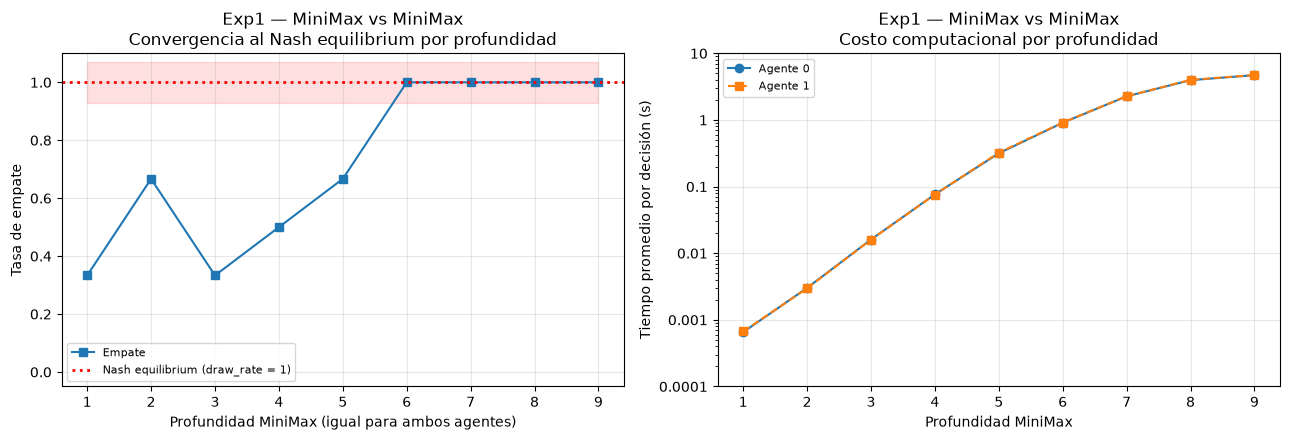

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_exp1.depth, df_exp1.draw_rate, marker='s', color='tab:blue', label='Empate')
axes[0].axhline(1.0, color='red', linestyle=':', linewidth=2, label='Nash equilibrium (draw_rate = 1)')
axes[0].fill_between(df_exp1.depth, 0.93, 1.07, alpha=0.12, color='red')
axes[0].set_xlabel('Profundidad MiniMax (igual para ambos agentes)')
axes[0].set_ylabel('Tasa de empate')
axes[0].set_title('Exp1 — MiniMax vs MiniMax\nConvergencia al Nash equilibrium por profundidad')
axes[0].set_xticks(depth_grid_mm)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

t0_s = df_exp1.avg_time_agente0_ms / 1000
t1_s = df_exp1.avg_time_agente1_ms / 1000
axes[1].plot(df_exp1.depth, t0_s, marker='o', label='Agente 0')
axes[1].plot(df_exp1.depth, t1_s, marker='s', linestyle='--', label='Agente 1')
axes[1].set_xlabel('Profundidad MiniMax')
axes[1].set_ylabel('Tiempo promedio por decisión (s)')
axes[1].set_title('Exp1 — MiniMax vs MiniMax\nCosto computacional por profundidad')
axes[1].set_xticks(depth_grid_mm)
axes[1].set_yscale('log')
set_log_ylim_nice(axes[1], t0_s, t1_s)
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp1_minimax_vs_minimax.png')
plt.show()

### Experimento 2 — MCTS vs MCTS: efecto del número de simulaciones

Se enfrenta MCTS **simétrico** (ambos agentes usan el mismo presupuesto) variando `simulations` en `[10, 25, 50, 100, 200, 500, 1000]`, con `rollouts=10` fijo. **Agente 0 juega N partidas como X y N como O**.

A medida que el presupuesto crece y ambos agentes se acercan al juego óptimo, el reward promedio de agente 0 debería converger a 0 (Nash = empate) y el `draw_rate` debería aumentar. Se usa un grid amplio (hasta 1000 simulaciones) para poder observar la tendencia de convergencia.

In [14]:
sim_grid_mcts = [10, 25, 50, 100, 200, 300, 500]
N_GAMES_MCTS_SIM_SIDE = 50  # por lado → 100 partidas por punto

t0 = time.perf_counter()
rows = []
for sims in sim_grid_mcts:
    print(f"[Exp2] simulations={sims} ...", end=" ", flush=True)
    agente0_spec = ('mcts', dict(simulations=sims, rollouts=10))
    agente1_spec = ('mcts', dict(simulations=sims, rollouts=10))
    rewards_a0, times_a0, times_a1 = run_symmetric(game, agente0_spec, agente1_spec, N_GAMES_MCTS_SIM_SIDE)
    n_total = 2 * N_GAMES_MCTS_SIM_SIDE
    avg_r = float(rewards_a0.mean())
    print(f"avg_reward={avg_r:+.3f}  (W={int((rewards_a0==1).sum())} D={int((rewards_a0==0).sum())} L={int((rewards_a0==-1).sum())})")
    rows.append(dict(
        simulations=sims,
        wins_agente0=int((rewards_a0 == 1).sum()),
        draws=int((rewards_a0 == 0).sum()),
        wins_agente1=int((rewards_a0 == -1).sum()),
        n_games=n_total,
        win_rate_agente0=float((rewards_a0 == 1).mean()),
        draw_rate=float((rewards_a0 == 0).mean()),
        win_rate_agente1=float((rewards_a0 == -1).mean()),
        avg_reward_agente0=avg_r,
        avg_time_agente0_ms=float(times_a0.mean()) * 1000,
        avg_time_agente1_ms=float(times_a1.mean()) * 1000,
    ))
experiment_times['Exp2: MCTS vs MCTS (simulaciones)'] = (
    time.perf_counter() - t0, len(sim_grid_mcts) * 2 * N_GAMES_MCTS_SIM_SIDE)

df_exp2 = pd.DataFrame(rows)
df_exp2

[Exp2] simulations=10 ... avg_reward=-0.080  (W=31 D=30 L=39)
[Exp2] simulations=25 ... avg_reward=+0.020  (W=30 D=42 L=28)
[Exp2] simulations=50 ... avg_reward=-0.010  (W=16 D=67 L=17)
[Exp2] simulations=100 ... avg_reward=+0.000  (W=3 D=94 L=3)
[Exp2] simulations=200 ... avg_reward=+0.000  (W=0 D=100 L=0)
[Exp2] simulations=300 ... avg_reward=+0.000  (W=0 D=100 L=0)
[Exp2] simulations=500 ... avg_reward=+0.000  (W=0 D=100 L=0)


,simulations,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,10,31,30,39,100,0.31,0.30,0.39,-0.08,10.702137,10.754240
1,25,30,42,28,100,0.30,0.42,0.28,0.02,25.456740,25.489874
2,50,16,67,17,100,0.16,0.67,0.17,-0.01,49.711388,49.788798
3,100,3,94,3,100,0.03,0.94,0.03,0.00,94.560416,95.069033
4,200,0,100,0,100,0.00,1.00,0.00,0.00,185.644825,185.406522
5,300,0,100,0,100,0.00,1.00,0.00,0.00,275.761115,275.079256
6,500,0,100,0,100,0.00,1.00,0.00,0.00,452.832707,453.568482


Figura guardada en ../informe/figures/TicTacToe/exp2_mcts_vs_mcts_simulations.png


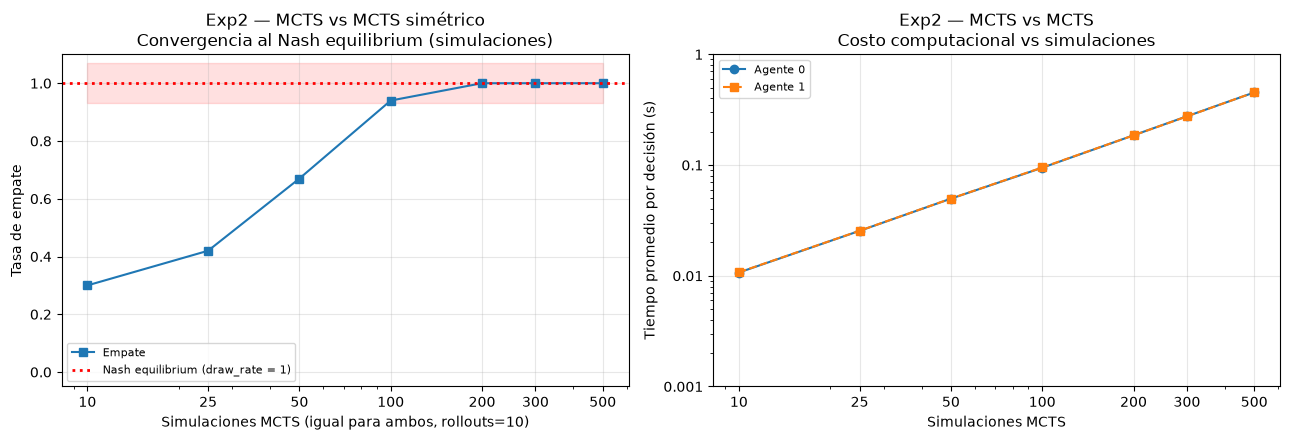

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(df_exp2.simulations, df_exp2.draw_rate, marker='s', color='tab:blue', label='Empate')
axes[0].axhline(1.0, color='red', linestyle=':', linewidth=2, label='Nash equilibrium (draw_rate = 1)')
axes[0].fill_between(df_exp2.simulations, 0.93, 1.07, alpha=0.12, color='red')
axes[0].set_xlabel('Simulaciones MCTS (igual para ambos, rollouts=10)')
axes[0].set_ylabel('Tasa de empate')
axes[0].set_title('Exp2 — MCTS vs MCTS simétrico\nConvergencia al Nash equilibrium (simulaciones)')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], sim_grid_mcts)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

t0_s = df_exp2.avg_time_agente0_ms / 1000
t1_s = df_exp2.avg_time_agente1_ms / 1000
axes[1].plot(df_exp2.simulations, t0_s, marker='o', label='Agente 0')
axes[1].plot(df_exp2.simulations, t1_s, marker='s', linestyle='--', label='Agente 1')
axes[1].set_xlabel('Simulaciones MCTS')
axes[1].set_ylabel('Tiempo promedio por decisión (s)')
axes[1].set_title('Exp2 — MCTS vs MCTS\nCosto computacional vs simulaciones')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], sim_grid_mcts)
axes[1].set_yscale('log')
set_log_ylim_nice(axes[1], t0_s, t1_s)
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp2_mcts_vs_mcts_simulations.png')
plt.show()

### Experimento 3 — MCTS vs MCTS: efecto del número de rollouts

Se enfrenta MCTS **simétrico** variando `rollouts` en `[1, 2, 5, 10, 15, 20, 30]`, con dos presupuestos de simulaciones fijos: **`simulations=50`** y **`simulations=100`**. **Agente 0 juega N partidas como X y N como O**.

Más rollouts reducen la varianza de la estimación del valor de cada nodo (promedio de más trayectorias aleatorias) pero aumentan el costo por simulación. El experimento mide si esta mejora en la estimación se traduce en convergencia al Nash equilibrium — y en particular, muestra que **con simulaciones bajas (`sims=50`) incrementar los rollouts no alcanza el equilibrio**: la tasa de empate converge a un techo por debajo de 1, mientras que con `sims=100` sí se llega al equilibrio para rollouts suficientes.

In [ ]:
rollout_grid = [1, 2, 5, 10, 15, 20, 30]
N_GAMES_MCTS_ROLL_SIDE = 80  # por lado
SIM_VALUES = [50, 120]

t0 = time.perf_counter()
rows = []
for sims in SIM_VALUES:
    for rollouts in rollout_grid:
        print(f"[Exp3] simulations={sims}, rollouts={rollouts} ...", end=" ", flush=True)
        agente0_spec = ('mcts', dict(simulations=sims, rollouts=rollouts))
        agente1_spec = ('mcts', dict(simulations=sims, rollouts=rollouts))
        rewards_a0, times_a0, times_a1 = run_symmetric(game, agente0_spec, agente1_spec, N_GAMES_MCTS_ROLL_SIDE)
        n_total = 2 * N_GAMES_MCTS_ROLL_SIDE
        avg_r = float(rewards_a0.mean())
        print(f"avg_reward={avg_r:+.3f}  (W={int((rewards_a0==1).sum())} D={int((rewards_a0==0).sum())} L={int((rewards_a0==-1).sum())})")
        rows.append(dict(
            simulations=sims,
            rollouts=rollouts,
            wins_agente0=int((rewards_a0 == 1).sum()),
            draws=int((rewards_a0 == 0).sum()),
            wins_agente1=int((rewards_a0 == -1).sum()),
            n_games=n_total,
            win_rate_agente0=float((rewards_a0 == 1).mean()),
            draw_rate=float((rewards_a0 == 0).mean()),
            win_rate_agente1=float((rewards_a0 == -1).mean()),
            avg_reward_agente0=avg_r,
            avg_time_agente0_ms=float(times_a0.mean()) * 1000,
            avg_time_agente1_ms=float(times_a1.mean()) * 1000,
        ))
experiment_times['Exp3: MCTS vs MCTS (rollouts)'] = (
    time.perf_counter() - t0, len(SIM_VALUES) * len(rollout_grid) * 2 * N_GAMES_MCTS_ROLL_SIDE)

experiment_times['Exp4: MCTS vs MiniMax'] = (
    time.perf_counter() - t0,
    len(sim_grid_exp4) * len(depth_grid_exp4) * 2 * N_GAMES_EXP4_SIDE)

df_exp4 = pd.DataFrame(rows)
df_exp4

[Exp3] simulations=50, rollouts=1 ... avg_reward=-0.031  (W=38 D=79 L=43)
[Exp3] simulations=50, rollouts=2 ... avg_reward=+0.019  (W=41 D=81 L=38)
[Exp3] simulations=50, rollouts=5 ... avg_reward=-0.044  (W=27 D=99 L=34)
[Exp3] simulations=50, rollouts=10 ... avg_reward=-0.037  (W=19 D=116 L=25)
[Exp3] simulations=50, rollouts=15 ... avg_reward=+0.044  (W=31 D=105 L=24)
[Exp3] simulations=50, rollouts=20 ... avg_reward=+0.019  (W=24 D=115 L=21)
[Exp3] simulations=50, rollouts=30 ... avg_reward=+0.019  (W=27 D=109 L=24)
[Exp3] simulations=120, rollouts=1 ... avg_reward=-0.013  (W=26 D=106 L=28)
[Exp3] simulations=120, rollouts=2 ... avg_reward=-0.019  (W=16 D=125 L=19)
[Exp3] simulations=120, rollouts=5 ... avg_reward=-0.037  (W=5 D=144 L=11)
[Exp3] simulations=120, rollouts=10 ... avg_reward=+0.000  (W=2 D=156 L=2)
[Exp3] simulations=120, rollouts=15 ... avg_reward=+0.013  (W=2 D=158 L=0)
[Exp3] simulations=120, rollouts=20 ... avg_reward=+0.000  (W=1 D=158 L=1)
[Exp3] simulations=120

Figura guardada en ../informe/figures/TicTacToe/exp3_mcts_vs_mcts_rollouts.png


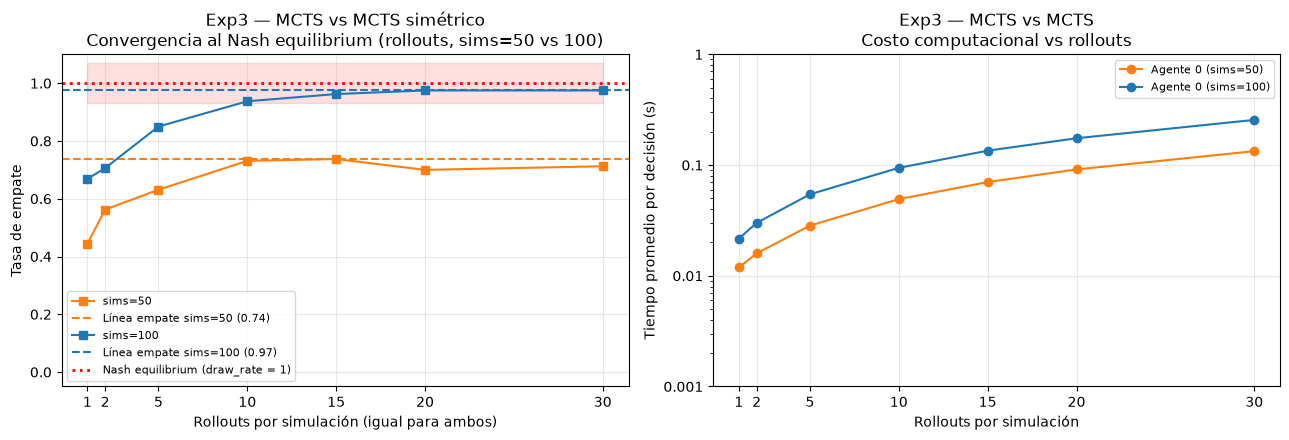

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {50: 'tab:orange', 100: 'tab:blue'}

for sims in SIM_VALUES:
    sub = df_exp3[df_exp3.simulations == sims].sort_values('rollouts')
    axes[0].plot(sub.rollouts, sub.draw_rate, marker='s', color=colors[sims], label=f'sims={sims}')
    # Línea empate por configuración: techo al que converge la draw_rate para este presupuesto
    empate_max = float(sub.draw_rate.max())
    axes[0].axhline(empate_max, color=colors[sims], linestyle='--', linewidth=1.5,
                    label=f'Línea empate sims={sims} ({empate_max:.2f})')

axes[0].axhline(1.0, color='red', linestyle=':', linewidth=2, label='Nash equilibrium (draw_rate = 1)')
axes[0].fill_between(rollout_grid, 0.93, 1.07, alpha=0.12, color='red')
axes[0].set_xlabel('Rollouts por simulación (igual para ambos)')
axes[0].set_ylabel('Tasa de empate')
axes[0].set_title('Exp3 — MCTS vs MCTS simétrico\nConvergencia al Nash equilibrium (rollouts, sims=50 vs 100)')
axes[0].set_xticks(rollout_grid)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

all_times = []
for sims in SIM_VALUES:
    sub = df_exp3[df_exp3.simulations == sims].sort_values('rollouts')
    t0_s = sub.avg_time_agente0_ms / 1000
    axes[1].plot(sub.rollouts, t0_s, marker='o', color=colors[sims], label=f'Agente 0 (sims={sims})')
    all_times.extend(t0_s.tolist())
    all_times.extend((sub.avg_time_agente1_ms / 1000).tolist())

axes[1].set_xlabel('Rollouts por simulación')
axes[1].set_ylabel('Tiempo promedio por decisión (s)')
axes[1].set_title('Exp3 — MCTS vs MCTS\nCosto computacional vs rollouts')
axes[1].set_xticks(rollout_grid)
axes[1].set_yscale('log')
set_log_ylim_nice(axes[1], all_times)
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp3_mcts_vs_mcts_rollouts.png')
plt.show()

### Experimento 4 — MCTS vs MiniMax: presupuesto MCTS vs profundidad MiniMax

Se enfrenta MCTS (agente 0, `simulations` variable) contra MiniMax (agente 1, `depth` 1–4 + depth=9). **Agente 0 juega N partidas como X y N como O**. MiniMax con `depth=9` (jugador Nash exacto) se trata con N reducido por costo computacional.

**Cómo leer la gráfica:** el reward promedio de agente 0 (MCTS) en función de la profundidad de MiniMax, con una curva por presupuesto de simulaciones. La línea roja es el Nash equilibrium (reward = 0). Si MCTS converge al equilibrio, su reward frente a MiniMax(depth=9) debería acercarse a 0 con más simulaciones.

In [32]:
sim_grid_exp4   = [50, 100, 200]
depth_grid_exp4 = [1, 2, 3, 4, 5, 6, 7]
N_GAMES_EXP4_SIDE = 20  # por lado

t0 = time.perf_counter()
rows = []

for sims in sim_grid_exp4:
    print(f"[Exp4] MCTS sims={sims}")
    for depth in depth_grid_exp4:
        print(f"  vs MiniMax depth={depth} ...", end=" ", flush=True)
        agente0_spec = ('mcts', dict(simulations=sims, rollouts=12))
        agente1_spec = ('minimax', dict(depth=depth))
        rewards_a0, times_a0, times_a1 = run_symmetric(
            game, agente0_spec, agente1_spec, N_GAMES_EXP4_SIDE)
        n_total = 2 * N_GAMES_EXP4_SIDE
        avg_r = float(rewards_a0.mean())
        print(f"avg_reward={avg_r:+.3f}  (W={int((rewards_a0==1).sum())} D={int((rewards_a0==0).sum())} L={int((rewards_a0==-1).sum())})")
        rows.append(dict(
            simulations=sims, minimax_depth=depth,
            wins_agente0=int((rewards_a0 == 1).sum()),
            draws=int((rewards_a0 == 0).sum()),
            wins_agente1=int((rewards_a0 == -1).sum()),
            n_games=n_total,
            win_rate_agente0=float((rewards_a0 == 1).mean()),
            draw_rate=float((rewards_a0 == 0).mean()),
            win_rate_agente1=float((rewards_a0 == -1).mean()),
            avg_reward_agente0=avg_r,
            avg_time_agente0_ms=float(times_a0.mean()) * 1000,
            avg_time_agente1_ms=float(times_a1.mean()) * 1000,
        ))

experiment_times['Exp4: MCTS vs MiniMax'] = (
    time.perf_counter() - t0,
    len(sim_grid_exp4) * len(depth_grid_exp4) * 2 * N_GAMES_EXP4_SIDE)

df_exp4 = pd.DataFrame(rows)
df_exp4

[Exp4] MCTS sims=50
  vs MiniMax depth=1 ... avg_reward=+0.850  (W=34 D=6 L=0)
  vs MiniMax depth=2 ... avg_reward=-0.075  (W=0 D=37 L=3)
  vs MiniMax depth=3 ... avg_reward=+0.075  (W=7 D=29 L=4)
  vs MiniMax depth=4 ... avg_reward=+0.150  (W=10 D=26 L=4)
  vs MiniMax depth=5 ... avg_reward=+0.100  (W=12 D=20 L=8)
  vs MiniMax depth=6 ... avg_reward=-0.175  (W=0 D=33 L=7)
  vs MiniMax depth=7 ... avg_reward=-0.250  (W=0 D=30 L=10)
[Exp4] MCTS sims=100
  vs MiniMax depth=1 ... avg_reward=+0.650  (W=27 D=12 L=1)
  vs MiniMax depth=2 ... avg_reward=+0.000  (W=0 D=40 L=0)
  vs MiniMax depth=3 ... avg_reward=+0.225  (W=11 D=27 L=2)
  vs MiniMax depth=4 ... avg_reward=+0.225  (W=9 D=31 L=0)
  vs MiniMax depth=5 ... avg_reward=+0.250  (W=10 D=30 L=0)
  vs MiniMax depth=6 ... avg_reward=+0.000  (W=0 D=40 L=0)
  vs MiniMax depth=7 ... avg_reward=-0.025  (W=0 D=39 L=1)
[Exp4] MCTS sims=200
  vs MiniMax depth=1 ... avg_reward=+0.775  (W=31 D=9 L=0)
  vs MiniMax depth=2 ... avg_reward=+0.000  (W=

,simulations,minimax_depth,wins_agente0,draws,wins_agente1,n_games,win_rate_agente0,draw_rate,win_rate_agente1,avg_reward_agente0,avg_time_agente0_ms,avg_time_agente1_ms
0,50,1,34,6,0,40,0.850,0.150,0.000,0.850,59.813191,0.685089
1,50,2,0,37,3,40,0.000,0.925,0.075,-0.075,56.032512,2.838790
2,50,3,7,29,4,40,0.175,0.725,0.100,0.075,57.502401,16.169527
3,50,4,10,26,4,40,0.250,0.650,0.100,0.150,58.467078,85.336205
4,50,5,12,20,8,40,0.300,0.500,0.200,0.100,58.302696,354.207369
5,50,6,0,33,7,40,0.000,0.825,0.175,-0.175,56.938012,1012.747857
6,50,7,0,30,10,40,0.000,0.750,0.250,-0.250,56.962600,2733.948120
7,100,1,27,12,1,40,0.675,0.300,0.025,0.650,113.165598,0.589596
8,100,2,0,40,0,40,0.000,1.000,0.000,0.000,110.699752,2.795090
9,100,3,11,27,2,40,0.275,0.675,0.050,0.225,108.509339,15.029649


Figura guardada en ../informe/figures/TicTacToe/exp4_mcts_vs_minimax.png


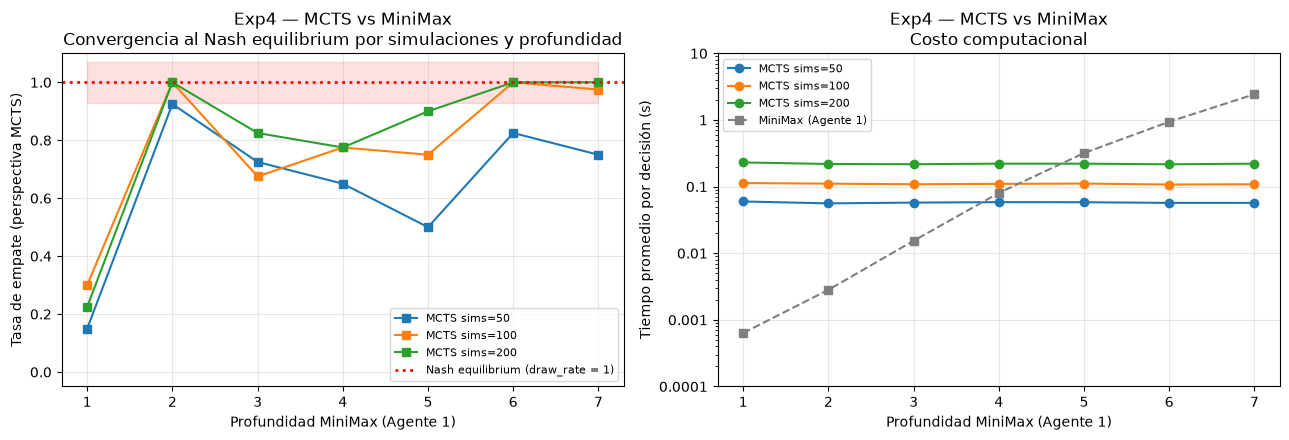

In [33]:
depth_list = sorted(df_exp4.minimax_depth.unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for sims in sim_grid_exp4:
    sub = df_exp4[df_exp4.simulations == sims]
    axes[0].plot(sub.minimax_depth, sub.draw_rate, marker='s', label=f'MCTS sims={sims}')
axes[0].axhline(1.0, color='red', linestyle=':', linewidth=2, label='Nash equilibrium (draw_rate = 1)')
axes[0].fill_between(depth_list, 0.93, 1.07, alpha=0.12, color='red')
axes[0].set_xlabel('Profundidad MiniMax (Agente 1)')
axes[0].set_ylabel('Tasa de empate (perspectiva MCTS)')
axes[0].set_title('Exp4 — MCTS vs MiniMax\nConvergencia al Nash equilibrium por simulaciones y profundidad')
axes[0].set_xticks(depth_list)
axes[0].set_ylim(-0.05, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

all_t0_s, all_t1_s = [], []
for sims in sim_grid_exp4:
    sub = df_exp4[df_exp4.simulations == sims]
    t0_s = sub.avg_time_agente0_ms / 1000
    axes[1].plot(sub.minimax_depth, t0_s, marker='o', label=f'MCTS sims={sims}')
    all_t0_s.extend(t0_s.tolist())
minimax_time_s = df_exp4.groupby('minimax_depth')['avg_time_agente1_ms'].mean() / 1000
axes[1].plot(minimax_time_s.index, minimax_time_s.values, marker='s', linestyle='--',
             color='tab:gray', label='MiniMax (Agente 1)')
all_t1_s.extend(minimax_time_s.tolist())
axes[1].set_xlabel('Profundidad MiniMax (Agente 1)')
axes[1].set_ylabel('Tiempo promedio por decisión (s)')
axes[1].set_title('Exp4 — MCTS vs MiniMax\nCosto computacional')
axes[1].set_xticks(depth_list)
axes[1].set_yscale('log')
set_log_ylim_nice(axes[1], all_t0_s, all_t1_s)
plain_log_yticks(axes[1])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
savefig(fig, 'exp4_mcts_vs_minimax.png')
plt.show()

### Experimento 4 — MCTS vs MiniMax con juego óptimo (`depth=9`)

Tic-Tac-Toe es un juego resuelto: con ambos jugadores jugando óptimamente el resultado teórico es **empate**. `MiniMax` sin poda alfa-beta a profundidad 9 explora el árbol completo desde el estado actual, por lo que jugar contra él (sobre todo cuando le toca mover primero, ~9! nodos) es costoso — se usan pocas partidas (`N_GAMES_EXP4`) sólo para contrastar el resultado contra el valor teórico del juego, no para estimar una tasa estadísticamente robusta.

**Cómo leer la tabla y el gráfico:** se juegan `N_GAMES_EXP4` partidas con MCTS como O (MiniMax como X) y otras `N_GAMES_EXP4` con MCTS como X (MiniMax como O); `reward_mcts` y el gráfico de barras siguientes están siempre desde la perspectiva de **MCTS** ("MCTS gana" / "Empate" / "MiniMax gana").

In [23]:
N_GAMES_EXP4 = 3  # MiniMax depth=9 sin poda es costoso (~40s/partida cuando mueve primero)

t0 = time.perf_counter()
specs_O = {'O': ('mcts', dict(simulations=200, rollouts=10)), 'X': ('minimax', dict(depth=9))}
df_O9 = run_match(game, specs_O, n_games=N_GAMES_EXP4)

specs_X = {'X': ('mcts', dict(simulations=200, rollouts=10)), 'O': ('minimax', dict(depth=9))}
df_X9 = run_match(game, specs_X, n_games=N_GAMES_EXP4)
experiment_times['Exp4: MCTS vs MiniMax óptimo (depth=9)'] = (time.perf_counter() - t0, 2 * N_GAMES_EXP4)

mcts_rewards_9 = pd.concat([df_O9['reward_O'], df_X9['reward_X']], ignore_index=True)

df_exp4 = pd.DataFrame({
    'posicion': ['O'] * N_GAMES_EXP4 + ['X'] * N_GAMES_EXP4,
    'reward_mcts': mcts_rewards_9,
})
print(df_exp4)
print()
print(f"MCTS (200 sims) vs MiniMax óptimo (depth=9): "
      f"win={float((mcts_rewards_9 == 1).mean()):.2f}, "
      f"draw={float((mcts_rewards_9 == 0).mean()):.2f}, "
      f"loss={float((mcts_rewards_9 == -1).mean()):.2f}")

  posicion  reward_mcts
0        O            0
1        O            0
2        O            0
3        X            0
4        X            0
5        X            0

MCTS (200 sims) vs MiniMax óptimo (depth=9): win=0.00, draw=1.00, loss=0.00


Figura guardada en ../informe/figures/TicTacToe/exp4_mcts_vs_optimal_minimax.png


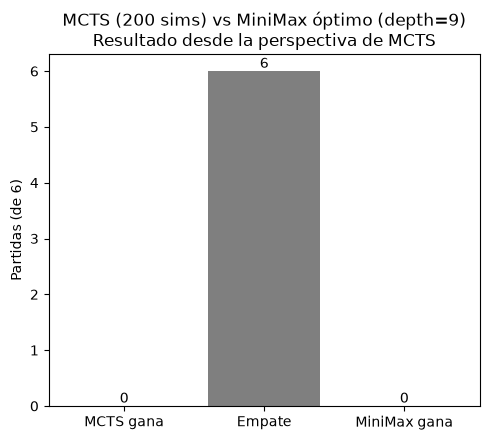

In [24]:
counts = mcts_rewards_9.value_counts().reindex([1, 0, -1], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
bars = ax.bar(['MCTS gana', 'Empate', 'MiniMax gana'], counts.values, color=['tab:green', 'tab:gray', 'tab:red'])
ax.bar_label(bars)
ax.set_ylabel(f'Partidas (de {len(mcts_rewards_9)})')
ax.set_title('MCTS (200 sims) vs MiniMax óptimo (depth=9)\nResultado desde la perspectiva de MCTS')
fig.tight_layout()
savefig(fig, 'exp4_mcts_vs_optimal_minimax.png')
plt.show()

### Benchmark de tiempos — comparación directa entre agentes (mismo N de partidas)

Los experimentos anteriores usan distinto número de partidas (`N_GAMES_EXP1`...`N_GAMES_EXP4`) porque el costo por partida varía órdenes de magnitud entre configuraciones — en particular, `MiniMax(depth=9)` sin poda cuesta hasta ~38 s en su primera jugada si le toca mover primero (árbol completo desde 9 casilleros vacíos). Para poder comparar el tiempo de decisión entre agentes con el **mismo N**, sin que ese costo extremo dispare la duración del benchmark, se arma un experimento dedicado:

- Cada agente bajo prueba juega siempre como **O** (segundo) contra **Random** fijo como **X**. Así, `MiniMax(depth=9)` parte de un tablero con sólo 8 casilleros vacíos en su primera jugada (~4 s en vez de ~38 s), y el costo total se mantiene manejable.
- Todos los agentes juegan exactamente `N_GAMES_BENCHMARK` partidas — el mismo N para todos, a diferencia de los experimentos de performance.
- Se mide el tiempo de decisión real de cada agente (`avg_time_O`), no de Random (que es ~0 y sólo cumple el rol de rival fijo y barato).

In [25]:
benchmark_configs = [
    ('Random', 'random', {}),
    ('MCTS (sims=10)', 'mcts', dict(simulations=10, rollouts=10)),
    ('MCTS (sims=50)', 'mcts', dict(simulations=50, rollouts=10)),
    ('MCTS (sims=100)', 'mcts', dict(simulations=100, rollouts=10)),
    ('MCTS (sims=200)', 'mcts', dict(simulations=200, rollouts=10)),
    ('MiniMax (depth=1)', 'minimax', dict(depth=1)),
    ('MiniMax (depth=2)', 'minimax', dict(depth=2)),
    ('MiniMax (depth=4)', 'minimax', dict(depth=4)),
    ('MiniMax (depth=9)', 'minimax', dict(depth=9)),
]
N_GAMES_BENCHMARK = 20  # mismo N para TODOS los agentes, incluido MiniMax(depth=9)

t0 = time.perf_counter()
rows = []
for label, kind, kwargs in benchmark_configs:
    # El agente bajo prueba juega siempre como O (segundo); Random siempre como X.
    # Así MiniMax(depth=9) arranca con 8 casilleros vacíos en vez de 9, mucho más barato.
    specs = {
        'O': (kind, kwargs),
        'X': ('random', {}),
    }
    df = run_match(game, specs, n_games=N_GAMES_BENCHMARK)
    rows.append(dict(
        agente=label,
        n_games=N_GAMES_BENCHMARK,
        avg_moves_per_game=df['n_moves_O'].mean(),
        avg_time_per_move_ms=df['avg_time_O'].mean() * 1000,
        total_decision_time_s=(df['avg_time_O'] * df['n_moves_O']).sum(),
    ))
experiment_times['Benchmark: tiempo por agente (N igual)'] = (time.perf_counter() - t0, len(benchmark_configs) * N_GAMES_BENCHMARK)

df_benchmark = pd.DataFrame(rows)
df_benchmark

,agente,n_games,avg_moves_per_game,avg_time_per_move_ms,total_decision_time_s
0,Random,20,3.35,0.006392,0.000424
1,MCTS (sims=10),20,3.15,12.809684,0.800684
2,MCTS (sims=50),20,3.35,47.324360,3.160089
3,MCTS (sims=100),20,3.15,92.404615,5.809177
4,MCTS (sims=200),20,3.20,180.076419,11.497564
5,MiniMax (depth=1),20,3.40,0.472997,0.031792
6,MiniMax (depth=2),20,3.10,3.051477,0.188011
7,MiniMax (depth=4),20,3.75,56.134657,4.088592
8,MiniMax (depth=9),20,3.55,1271.600982,88.512861


Figura guardada en ../informe/figures/TicTacToe/benchmark_tiempos_por_agente.png


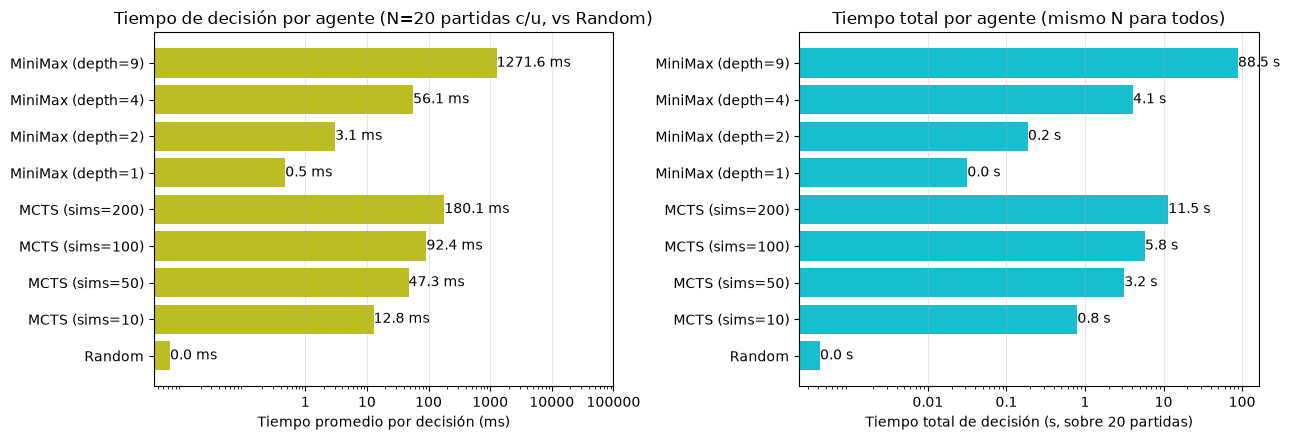

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars0 = axes[0].barh(df_benchmark.agente, df_benchmark.avg_time_per_move_ms, color='tab:olive')
axes[0].bar_label(bars0, fmt='%.1f ms')
axes[0].set_xlabel('Tiempo promedio por decisión (ms)')
axes[0].set_title(f'Tiempo de decisión por agente (N={N_GAMES_BENCHMARK} partidas c/u, vs Random)')
axes[0].set_xscale('log')
plain_log_xticks(axes[0], [1, 10, 100, 1000, 10000, 100000])
axes[0].grid(alpha=0.3, axis='x')

bars1 = axes[1].barh(df_benchmark.agente, df_benchmark.total_decision_time_s, color='tab:cyan')
axes[1].bar_label(bars1, fmt='%.1f s')
axes[1].set_xlabel(f'Tiempo total de decisión (s, sobre {N_GAMES_BENCHMARK} partidas)')
axes[1].set_title('Tiempo total por agente (mismo N para todos)')
axes[1].set_xscale('log')
plain_log_xticks(axes[1], [0.01, 0.1, 1, 10, 100])
axes[1].grid(alpha=0.3, axis='x')

fig.tight_layout()
savefig(fig, 'benchmark_tiempos_por_agente.png')
plt.show()

### Tiempos de ejecución — resumen

Tabla consolidada con el tiempo total de cómputo (wall-clock) y la cantidad de partidas jugadas en cada bloque experimental, complementando los tiempos de decisión por jugada ya reportados dentro de cada experimento.

In [27]:
df_times = pd.DataFrame([
    {
        'experimento': name,
        'tiempo_total_s': t,
        'partidas_jugadas': n,
        'tiempo_por_partida_s': t / n,
    }
    for name, (t, n) in experiment_times.items()
])

total_row = pd.DataFrame([{
    'experimento': 'TOTAL',
    'tiempo_total_s': df_times.tiempo_total_s.sum(),
    'partidas_jugadas': df_times.partidas_jugadas.sum(),
    'tiempo_por_partida_s': df_times.tiempo_total_s.sum() / df_times.partidas_jugadas.sum(),
}])
df_times = pd.concat([df_times, total_row], ignore_index=True)
df_times

,experimento,tiempo_total_s,partidas_jugadas,tiempo_por_partida_s
0,Exp1: MiniMax vs MiniMax (depth 1–9),710.529825,54,13.157960
1,Exp2: MCTS vs MCTS (simulaciones),972.131873,700,1.388760
2,Exp3: MCTS vs MCTS (rollouts),1823.264284,1440,1.266156
3,Exp4: MCTS vs MiniMax,1446.269052,960,1.506530
4,Exp4: MCTS vs MiniMax óptimo (depth=9),132.841926,6,22.140321
5,Benchmark: tiempo por agente (N igual),114.119311,180,0.633996
6,TOTAL,5199.156271,3340,1.556634


Figura guardada en ../informe/figures/TicTacToe/exp_timing_summary.png


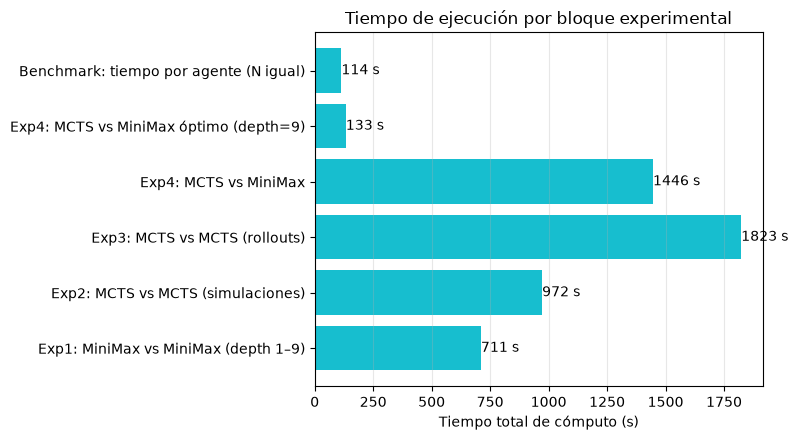

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = df_times[df_times.experimento != 'TOTAL']
bars = ax.barh(plot_df.experimento, plot_df.tiempo_total_s, color='tab:cyan')
ax.bar_label(bars, fmt='%.0f s')
ax.set_xlabel('Tiempo total de cómputo (s)')
ax.set_title('Tiempo de ejecución por bloque experimental')
ax.grid(alpha=0.3, axis='x')
fig.tight_layout()
savefig(fig, 'exp_timing_summary.png')
plt.show()